**CREATING A CLASSIFICATION DATASET**

In [11]:
from sklearn.datasets import make_classification
import numpy as np
x, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=20)

In [12]:
x.shape

(100, 2)

In [13]:
y.shape

(100,)

for the visualisation and ploting

In [14]:

import matplotlib.pyplot as plt

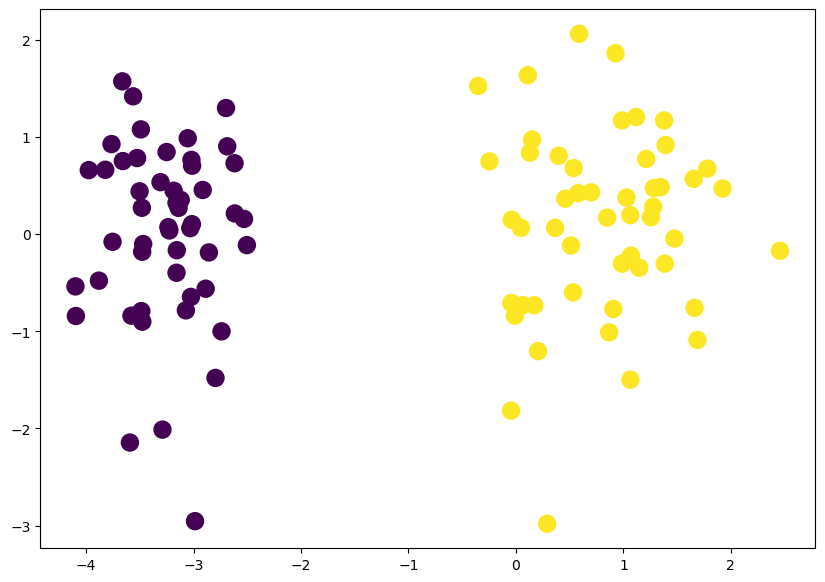

In [15]:

plt.figure(figsize=(10,7))
plt.scatter(x[:,0],x[:,1],c=y,s=150)

**LOGISTIC REGRESSION FROM SKLEARN**

In [16]:
from sklearn.linear_model import LogisticRegression
logir = LogisticRegression()
logir.fit(x,y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


so this is the best classifying line which has the following coefficients

In [17]:

print(f"W1,W2:{logir.coef_}")
print(f"W0:{logir.intercept_}")

W1,W2:[[2.36679363 0.02300492]]
W0:[3.13571596]


calculating the sloppe and the intercept using the formula
slope(m1)=w1/w2
intercept(b)=w0/w2

In [18]:

m1 = -(logir.coef_[0][0]/logir.coef_[0][1])
b1 = -(logir.intercept_/logir.coef_[0][1])
print(m1)
print(b1)

-102.88205179540347
[-136.30630349]


now x is 100 points that cretaes a line like with continous points and the x is used in the y line

In [19]:

x_line = np.linspace(-3,3,100)
y_line = m1*x_line + b1

(-3.0, 2.0)

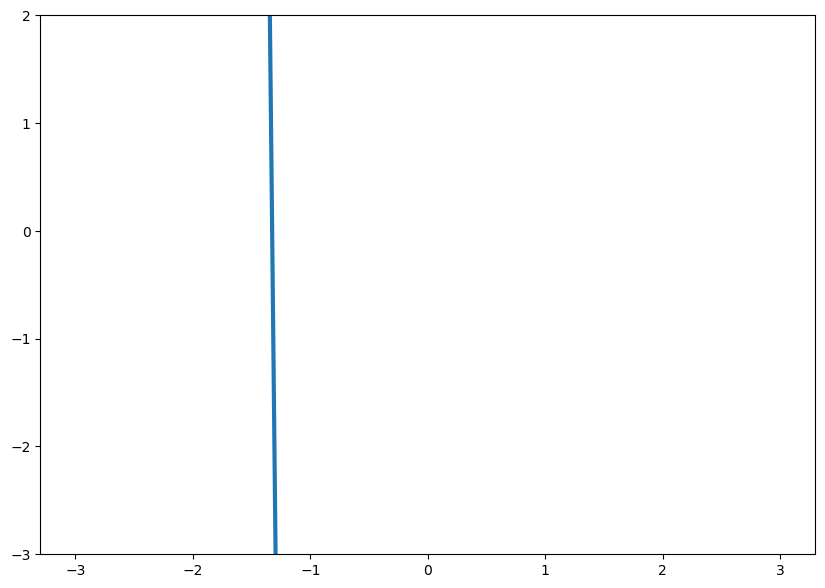

In [20]:
plt.figure(figsize=(10,7))
plt.plot(x_line,y_line,linewidth=3)
# plt.scatter(x[:,0],x[:,1],c=y,s=150)
plt.ylim(-3,2)

**USING THE GRADIENT DESCENT FOR MINIMIZING THE LOSS FUNCTIONA AND FIND THE DERIVATIVES TO UPDATE THE WEIGHT(W)**

initially the weights are assigned 1

In [21]:
def gd(x,y):
    
    x = np.insert(x,0,1,axis=1)
    weights = np.ones(x.shape[1])
    lr = 0.5
    
    for i in range(5000):
        y_hat = sigmoid(np.dot(x,weights))
        weights = weights + lr*(np.dot((y-y_hat),x)/x.shape[0])
        
    return weights[1:],weights[0]
        

**Defining the activation fuction(SIGMOID)**

In [22]:

def sigmoid(z):
    return 1/(1 + np.exp(-z))

In [23]:
coef_,intercept_ = gd(x,y)

calc the slope ie the m and b

In [24]:

m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [25]:
x_line_gd = np.linspace(-3,3,100)
y_line_gd = m*x_line_gd + b

(-3.0, 2.0)

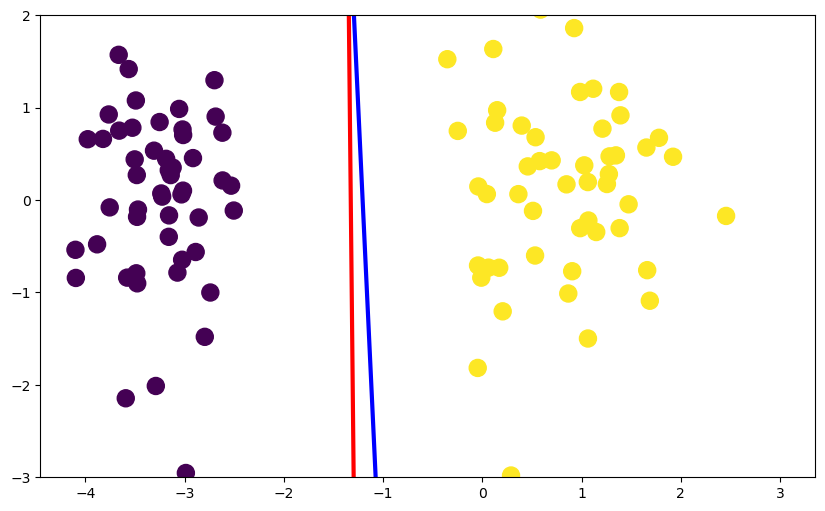

In [28]:
plt.figure(figsize=(10,6))
plt.plot(x_line,y_line,color='red',linewidth=3)
plt.plot(x_line_gd,y_line_gd,color='blue',linewidth=3)
plt.scatter(x[:,0],x[:,1],c=y,s=150)
plt.ylim(-3,2)

**ALMOST THE SAME THSI CAN BE DONE WITH JUST TEN LINES USING PYTORCH**